# Build one local datacube for a small ROI

[Explore Data](https://sunnydean.github.io/ocean_cubes_vis/?cube=https%3A%2F%2Fs3.waw4-1.cloudferro.com%2FEarthCODE%2FOSCAssets%2Fmed_cubes%2Focean-med-daily-surface-cube.zarr&variable=sos)

Create a small local cube using the 4DMED-SEA sea-surface salinity source dataset (`sos`), available as Zarr on its native grid. The [dataset notebook](../1_Datasets/4dmed-ss/access.ipynb) describes this input.

The example selects one day in a 2° by 2° Alboran Sea region, resamples it to a 1/12° grid, applies the WorldCover water retention mask, saves it as Zarr, and plots the result.

The [overview](0_intro.ipynb) describes the original cube workflows.

In [11]:
from pathlib import Path

import geopandas as gpd
import numpy as np
import rioxarray
import xarray as xr
import matplotlib.pyplot as plt
from dask.diagnostics import ProgressBar
from rasterio.enums import Resampling
from rioxarray.merge import merge_arrays

AOI_CENTER_LON_LAT = (-2.5, 36.0)
AOI_WIDTH_DEG = 2.0
TARGET_RESOLUTION_DEG = 1 / 12
TIME_TARGET = "2019-06-01"

# Work from either the repository root or the notebook directory.
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "myst.yml").exists() else Path.cwd().parent
OUTPUT_DIR = PROJECT_ROOT / "downloaded_data"
FINAL_CUBE = OUTPUT_DIR / "alboran_daily_demo_cube.zarr"

## 1. Open the Source Dataset

Open the 4DMED-SEA salinity dataset. The data remain lazy until the selected region is written below.

In [12]:
INPUT_PATH = "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/ocean_datasets/sssd.zarr"
source_dataset = xr.open_zarr(
    INPUT_PATH, chunks={}, decode_coords="all",
)

## 2. Select and Resample a Small Region

Create the new grid, select surface salinity (`depth=0`) for one day, and copy the nearest source value to each target cell. A small buffer around the region supplies neighbouring cells for interpolation. Missing values remain missing.

The default settings produce a 24 × 24 grid. The date slice includes the source observation for that day, normally timestamped at noon, and keeps its time dimension.

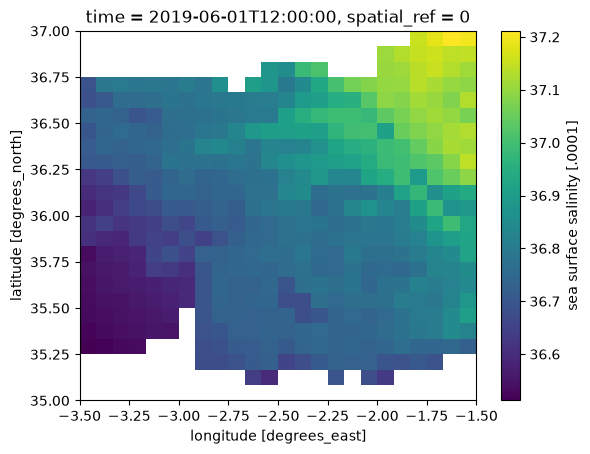

In [15]:
half_width = AOI_WIDTH_DEG / 2
left, right = AOI_CENTER_LON_LAT[0] - half_width, AOI_CENTER_LON_LAT[0] + half_width
bottom, top = AOI_CENTER_LON_LAT[1] - half_width, AOI_CENTER_LON_LAT[1] + half_width

n_cells = int(round(AOI_WIDTH_DEG / TARGET_RESOLUTION_DEG))
offsets = (np.arange(n_cells) + 0.5) * TARGET_RESOLUTION_DEG
target_lon = left + offsets
target_lat = bottom + offsets

source = source_dataset[["sos"]].sel(
    time=slice(TIME_TARGET, TIME_TARGET), depth=0, drop=True,
    lon=slice(left - 0.25, right + 0.25),
    lat=slice(bottom - 0.25, top + 0.25),
)
cube = source.interp(lon=target_lon, lat=target_lat, method="nearest")
cube = cube.rio.write_crs("EPSG:4326").rio.set_spatial_dims(x_dim="lon", y_dim="lat")
cube.sos.isel(time=0).plot()

## 3. Apply the WorldCover Water Retention Mask

Read the roughly 320 m overviews of the ESA WorldCover 2021 tiles covering this region. Classes `0` (unmapped) and `80` (permanent water) are retained. Minimum resampling excludes a target cell if it contains mapped land; areas outside the mosaic remain retained. Unmapped areas are not confirmed water.

Apply the spatial mask to salinity across time and keep `water_mask` in the output (`1` retained, `0` excluded).

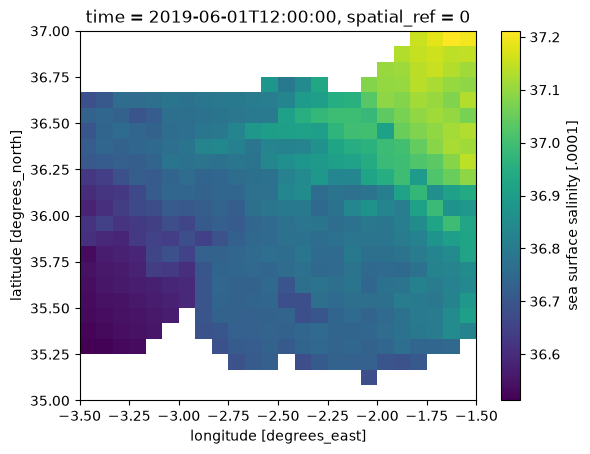

In [16]:
left, bottom, right, top = cube.rio.bounds()
WC_BASE = "https://esa-worldcover.s3.eu-central-1.amazonaws.com"
tiles = gpd.read_file(f"{WC_BASE}/v100/2020/esa_worldcover_2020_grid.geojson").cx[left:right, bottom:top]
wc = merge_arrays([
    rioxarray.open_rasterio(
        f"{WC_BASE}/v200/2021/map/ESA_WorldCover_10m_2021_v200_{tile}_Map.tif",
        overview_level=4,
    )
    for tile in sorted(tiles.ll_tile)
], nodata=0).squeeze("band", drop=True)

water = wc.isin([0, 80]).astype("uint8").rio.write_nodata(255)
water_mask = water.rio.reproject_match(cube, resampling=Resampling.min, nodata=255)
water_mask = water_mask.where(water_mask != 255, 1)
water_mask = water_mask.rename({"x": "lon", "y": "lat"}).rename("water_mask")
cube["sos"] = cube.sos.where(water_mask == 1)
cube["water_mask"] = water_mask
cube.sos.isel(time=0).plot()

## 4. Save the Local Cube

Record the coordinate system, grid spacing, and source, then write the masked salinity and `water_mask` to `downloaded_data/alboran_daily_demo_cube.zarr`.

`mode="w-"` keeps an existing result from being overwritten. Choose a new output filename to run the write again.

In [18]:
cube.attrs = {
    "title": "Alboran Sea salinity demonstration cube",
    "crs": "EPSG:4326",
    "target_resolution_degrees": TARGET_RESOLUTION_DEG,
    "source_store": INPUT_PATH,
    "interpolation_method": "nearest",
}

# Clear the source storage settings before writing the new grid.
for name in cube.variables:
    cube[name].encoding = {}
for name in cube.data_vars:
    cube[name].attrs["grid_mapping"] = "spatial_ref"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
with ProgressBar():
    cube.chunk({"time": 1, "lat": -1, "lon": -1}).to_zarr(
        FINAL_CUBE, mode="w", consolidated=True, zarr_format=2,
    )

[########################################] | 100% Completed | 1.61 sms


## 5. Open and Plot the Result

Read the local cube and plot sea-surface salinity for the selected day.

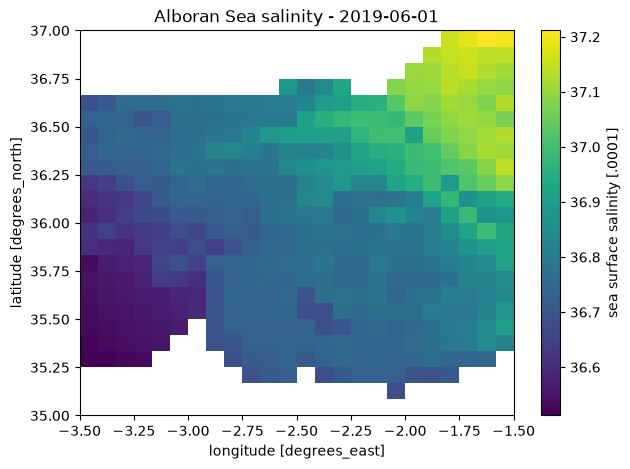

In [19]:
demo_cube = xr.open_zarr(FINAL_CUBE, consolidated=True, decode_coords="all")
demo_cube.sos.isel(time=0).plot(figsize=(7, 5), cmap="viridis")
plt.title(f"Alboran Sea salinity - {TIME_TARGET}")
plt.show()

demo_cube.close()
source_dataset.close()